# Producing an Interferogram from Two NISAR GSLCs
<br>

This notebook demonstrates how to generate an interferogram from a pair of NISAR Geocoded Single-Look Complex (GSLC) products. The workflow includes searching for data, accessing GSLCs through downloading or cloud streaming, selecting a polarization, defining an (optional) area of interest, generating an interferogram, visualizing the resulting wrapped phase, and exporting files.

<br>

This example uses NISAR GSLC products, which provide geocoded complex SAR imagery suitable for interferometric analysis and other advanced SAR applications. The NISAR data in this notebook captures the eruption of Ethiopia's Hayli Gubbi Volcano on November 23, 2025. For more information on the eruption, [follow this link](https://www.earthdata.nasa.gov/news/worldview-image-archive/first-documented-eruption-ethiopias-hayli-gubbi-volcano). For more information on NISAR GSLC data, refer to the [NISAR Data User Guide](https://nisar-docs.asf.alaska.edu/gslc/). 

::: {dropdown} More Information on Interferometry

Interferometry compares the phase of two SAR images acquired over the same area at different times. This notebook demonstrates one of the simplest approaches for creating an interferogram from a pair of NISAR GSLC products: multiplying one complex image by the complex conjugate of another.

The resulting interferogram contains wrapped phase values ranging from $-\pi$ to $\pi$. These phase differences may be caused by topography, surface displacement, atmospheric effects, or changes in scattering properties between acquisitions.

This example focuses on generating and visualizing a wrapped interferogram and is intended as an introduction to interferometric processing with NISAR GSLC products.

:::

## Overview

1. [Prerequisites](gslcifg-prereqs)
1. [Search for Data](gslcifg-search)
2. [Select Data Access Option](gslcifg-dataaccess)
1. [Open and Inspect GSLCs](gslcifg-open)
1. [Select Input Data](gslcifg-prepdata)
1. [Define and Visualize a Subset](gslcifg-subset)
1. [Create and Visualize a Subsetted Interferogram](gslcifg-subsetifg)
1. [Create a and Visualize a Scene-Wide Interferogram](gslcifg-sceneifg)
1. [Export Files](gslcifg-exports)
1. [Summary](gslcifg-summary)
1. [Resources and references](gslcifg-resources)

<hr>

(gslcifg-prereqs)=
## 1. Prerequisites

| Prerequisite | Importance | Notes |
| --- | --- | --- |
| [The `isce3` software environment for this cookbook](software_environment_docker.ipynb) | Necessary | |
| [How to search and access NISAR data in your {abbr}`AOI (area of interest)`](search_download_NISAR_GCOV_asf_search.ipynb) | Necessary | If you wish to process data in your AOI instead of the example data |
| [Familiarity with xarray](https://docs.xarray.dev/en/stable/) | Helpful | |
| General knowledge of interferometry | Helpful |

- **Rough Notebook Time Estimate**: 15 mins 

<hr>

(gslcifg-search)=
## 2. Search for data

Use `asf_search` to find GSLC data.

### 2a. Perform an `asf_search.search()` to identify your desired product URLs


In [1]:
import os
import asf_search as asf
from datetime import datetime
from getpass import getpass

import warnings
warnings.filterwarnings(
    "ignore",
    message="Parsing dates involving a day of month without a year specified",
)

session = asf.ASFSession()

start_date = datetime(2025, 11, 21)
end_date = datetime(2025, 12, 7)
area_of_interest = "POLYGON((40.1106 12.4104,41.8474 12.4104,41.8474 14.2538,40.1106 14.2538,40.1106 12.4104))" # POINT or POLYGON as WKT (well-known-text)
pattern = r'^(?!.*QA_STATS).*'

opts=asf.ASFSearchOptions(**{
    "maxResults": 250,
    "intersectsWith": area_of_interest,
    "flightDirection": "ASCENDING",
    "start": start_date,
    "end": end_date,
    "relativeOrbit": 172,
    "frame": 8,
    "processingLevel": [
        "GSLC"
    ],
    "dataset": [
        "NISAR"
    ],
    "productionConfiguration": [
        "PR"
    ],
    'session': session,
})

response = asf.search(opts=opts)
hdf5_urls = response.find_urls(extension='.h5', pattern=pattern, directAccess=False)
print(f"Found {len(hdf5_urls)} GSLC products:")
hdf5_urls

Found 4 GSLC products:


['https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GSLC_BETA_V1/NISAR_L2_PR_GSLC_005_172_A_008_2005_DHDH_A_20251122T024618_20251122T024652_X05007_N_F_J_001/NISAR_L2_PR_GSLC_005_172_A_008_2005_DHDH_A_20251122T024618_20251122T024652_X05007_N_F_J_001.h5',
 'https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GSLC_BETA_V1/NISAR_L2_PR_GSLC_005_172_A_008_2005_DHDH_A_20251122T024618_20251122T024652_X05009_N_F_J_001/NISAR_L2_PR_GSLC_005_172_A_008_2005_DHDH_A_20251122T024618_20251122T024652_X05009_N_F_J_001.h5',
 'https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GSLC_BETA_V1/NISAR_L2_PR_GSLC_006_172_A_008_2005_DHDH_A_20251204T024618_20251204T024653_X05007_N_F_J_001/NISAR_L2_PR_GSLC_006_172_A_008_2005_DHDH_A_20251204T024618_20251204T024653_X05007_N_F_J_001.h5',
 'https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GSLC_BETA_V1/NISAR_L2_PR_GSLC_006_172_A_008_2005_DHDH_A_20251204T024618_20251204T024653_X05009_N_F_J_001/NISAR_L2_PR_GSLC_006_172_A_008_2005_DHDH_A_20251204T0

### 2b. Retain only the URL for the most recent version of each product in the search results

Data is occasionally re-released with an updated version. Versions are recorded as a [Composite Release Identifier (CRID)](https://nisar-docs.asf.alaska.edu/naming-conventions/) in a product's filename. We can use the CRID to retain only the most recent version of each product in the list of URLs.

In [2]:
import re

pattern = re.compile(
    r"(NISAR_L2_PR_GSLC.*?)_X([0-9]{5})_N_F_J_[0-9]{3}\.h5$"
)

latest_version_dict = {}

for url in hdf5_urls:
    fname = url.split("/")[-1]

    m = pattern.search(fname)
    if not m:
        print(f"No match: {fname}")
        continue

    product, crid = m.groups()

    if product not in latest_version_dict or crid > latest_version_dict[product][0]:
        latest_version_dict[product] = (crid, url)

hdf5_urls = [i[1] for i in latest_version_dict.values()]

print(f"Retained {len(hdf5_urls)} GSLC products:")
hdf5_urls

Retained 2 GSLC products:


['https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GSLC_BETA_V1/NISAR_L2_PR_GSLC_005_172_A_008_2005_DHDH_A_20251122T024618_20251122T024652_X05009_N_F_J_001/NISAR_L2_PR_GSLC_005_172_A_008_2005_DHDH_A_20251122T024618_20251122T024652_X05009_N_F_J_001.h5',
 'https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GSLC_BETA_V1/NISAR_L2_PR_GSLC_006_172_A_008_2005_DHDH_A_20251204T024618_20251204T024653_X05009_N_F_J_001/NISAR_L2_PR_GSLC_006_172_A_008_2005_DHDH_A_20251204T024618_20251204T024653_X05009_N_F_J_001.h5']

(gslcifg-dataaccess)=
## 3. Select Data Access Options

This notebook can be run locally or on OpenScienceLab. Users may either download the GSLC files or stream them directly from the cloud. If running locally, consider streaming data with HTTPS to avoid downloading large GSLC files.

<br>


### 3a. Option 1: Download the data 

In [3]:
from pathlib import Path

# Create a folder and download the files
data_dir = Path.home() / "GSLC_data"
data_dir.mkdir(exist_ok=True)
print(f'data_dir: {data_dir}')

#download files
asf.download_urls(hdf5_urls, data_dir, session=session, processes=4)

data_dir: /home/jovyan/GSLC_data


In [4]:
gslc_files = sorted(data_dir.glob("*.h5"))
gslc_files

[PosixPath('/home/jovyan/GSLC_data/NISAR_L2_PR_GSLC_005_172_A_008_2005_DHDH_A_20251122T024618_20251122T024652_X05009_N_F_J_001.h5'),
 PosixPath('/home/jovyan/GSLC_data/NISAR_L2_PR_GSLC_006_172_A_008_2005_DHDH_A_20251204T024618_20251204T024653_X05009_N_F_J_001.h5')]

### 3b. Option 2: Stream Data with HTTPS

:::{note} HTTPS direct access works outside of AWS region us-west-2

HTTPS access does not require execution within the same AWS region as the data, so it can be performed from a local computer or HPC. However, HTTPS access is slower than other data access options.
:::

### Provide your Earthdata Login (EDL) Bearer Token

HTTPS requires an EDL Bearer Token

:::{figure} ../assets/edl_token.png
:alt: Image of the Earthdata Login Generate Token web page
:width: 75%
:align: left

View or generate a Bearer Token in "Generate Token" tab of the Profile page in your Earthdata Login account: https://urs.earthdata.nasa.gov/profile
:::

:::{note} Temporary S3 credentials

The S3 credentials acquired below expire after 1 hour.
:::

In [ ]:
from getpass import getpass

token = getpass("Enter your EDL Bearer Token")

In [ ]:
%%time
import fsspec
import xarray as xr

fs = fsspec.filesystem(
    "http",
    headers={"Authorization": f"Bearer {token}"},
)

group_path = "/science/LSAR/GSLC/grids/frequencyA"

kwargs = {
    "cache_type": "background",
    "block_size": 8 * 1024 * 1024,  # 8 MB
}

gslc_files = [
    fs.open(url, "rb", **kwargs)
    for url in hdf5_urls
]

(gslcifg-open)=
## 4. Open and inspect GSLCs 

Open each GSLC as an `xarray.DataTree` to inspect the files and view available polarizations 

<br>

In [5]:
import xarray as xr

gslc_dt = [
    xr.open_datatree(
        f,
        engine="h5netcdf",
        decode_timedelta=False,
        phony_dims="access",
        chunks="auto",
        group="/science/LSAR/GSLC/grids/frequencyA",
    )
    for f in gslc_files
]

In [6]:
gslc_dt[0]

<xarray.DataTree>
Group: /
    Dimensions:                 (yCoordinates: 66816, xCoordinates: 34128,
                                 phony_dim_0: 2)
    Coordinates:
      * yCoordinates            (yCoordinates) float64 535kB 1.588e+06 ... 1.254e+06
      * xCoordinates            (xCoordinates) float64 273kB 6.041e+05 ... 9.454e+05
    Dimensions without coordinates: phony_dim_0
    Data variables: (12/13)
        HH                      (yCoordinates, xCoordinates) complex64 18GB dask.array<chunksize=(4096, 4096), meta=np.ndarray>
        HV                      (yCoordinates, xCoordinates) complex64 18GB dask.array<chunksize=(4096, 4096), meta=np.ndarray>
        azimuthBandwidth        float64 8B ...
        centerFrequency         float64 8B ...
        listOfPolarizations     (phony_dim_0) |S2 4B dask.array<chunksize=(2,), meta=np.ndarray>
        mask                    (yCoordinates, xCoordinates) float32 9GB dask.array<chunksize=(5632, 5632), meta=np.ndarray>
        ...                      ...
        projection              uint32 4B ...
        rangeBandwidth          float64 8B ...
        slantRangeSpacing       float64 8B ...
        xCoordinateSpacing      float64 8B ...
        yCoordinateSpacing      float64 8B ...
        zeroDopplerTimeSpacing  float64 8B ...

In [7]:
gslc_dt[1]

<xarray.DataTree>
Group: /
    Dimensions:                 (yCoordinates: 66816, xCoordinates: 34128,
                                 phony_dim_0: 2)
    Coordinates:
      * yCoordinates            (yCoordinates) float64 535kB 1.588e+06 ... 1.254e+06
      * xCoordinates            (xCoordinates) float64 273kB 6.041e+05 ... 9.454e+05
    Dimensions without coordinates: phony_dim_0
    Data variables: (12/13)
        HH                      (yCoordinates, xCoordinates) complex64 18GB dask.array<chunksize=(4096, 4096), meta=np.ndarray>
        HV                      (yCoordinates, xCoordinates) complex64 18GB dask.array<chunksize=(4096, 4096), meta=np.ndarray>
        azimuthBandwidth        float64 8B ...
        centerFrequency         float64 8B ...
        listOfPolarizations     (phony_dim_0) |S2 4B dask.array<chunksize=(2,), meta=np.ndarray>
        mask                    (yCoordinates, xCoordinates) float32 9GB dask.array<chunksize=(5632, 5632), meta=np.ndarray>
        ...                      ...
        projection              uint32 4B ...
        rangeBandwidth          float64 8B ...
        slantRangeSpacing       float64 8B ...
        xCoordinateSpacing      float64 8B ...
        yCoordinateSpacing      float64 8B ...
        zeroDopplerTimeSpacing  float64 8B ...

(gslcifg-prepdata)=

## 5. Select Input Data

Prepare the interferogram by:

- Selecting a polarization
- Choosing the reference (primary) GSLC
- Choosing the secondary GSLC
- Defining a spatial subset (optional)

### 5a. Select a polarization and view data
Available polarizations can be viewed in either `xarray.DataTree` in Section 4.

In [8]:
pol = "HH"

### 5b. Assign Primary and Secondary Files

In [9]:
ref_file = gslc_dt[0][pol]
sec_file = gslc_dt[1][pol]

(gslcifg-subset)=
## 6. Define and Visualize a Subset

Optionally define a spatial subset to reduce processing time and focus the analysis on a specific area of interest. The subset can be specified using a WKT polygon and visualized before generating the interferogram. To draw and copy/paste a WKT, use the AOI "Draw a Box" tool on the [ASF Data Search](https://search.asf.alaska.edu/#/) website.

<br>


In [10]:
#define epsg for subsetting and writing exports 

epsg = int(gslc_dt[0].projection.attrs["epsg_code"])

epsg

32637

In [11]:
#define area of interest 

wkt = "POLYGON((40.5327 13.4179,40.8702 13.4179,40.8702 13.7066,40.5327 13.7066,40.5327 13.4179))"

In [12]:
import rioxarray
from shapely import wkt as shapely_wkt
from rasterio.warp import transform_bounds

epsg = int(gslc_dt[0].projection.attrs["epsg_code"])
crs = f"EPSG:{epsg}"

ref_file = ref_file.rio.write_crs(crs)
sec_file = sec_file.rio.write_crs(crs)

geom = shapely_wkt.loads(wkt)

bounds = transform_bounds(
    "EPSG:4326",
    crs,
    *geom.bounds
)

ref_subset = ref_file.rio.clip_box(*bounds)
sec_subset = sec_file.rio.clip_box(*bounds)

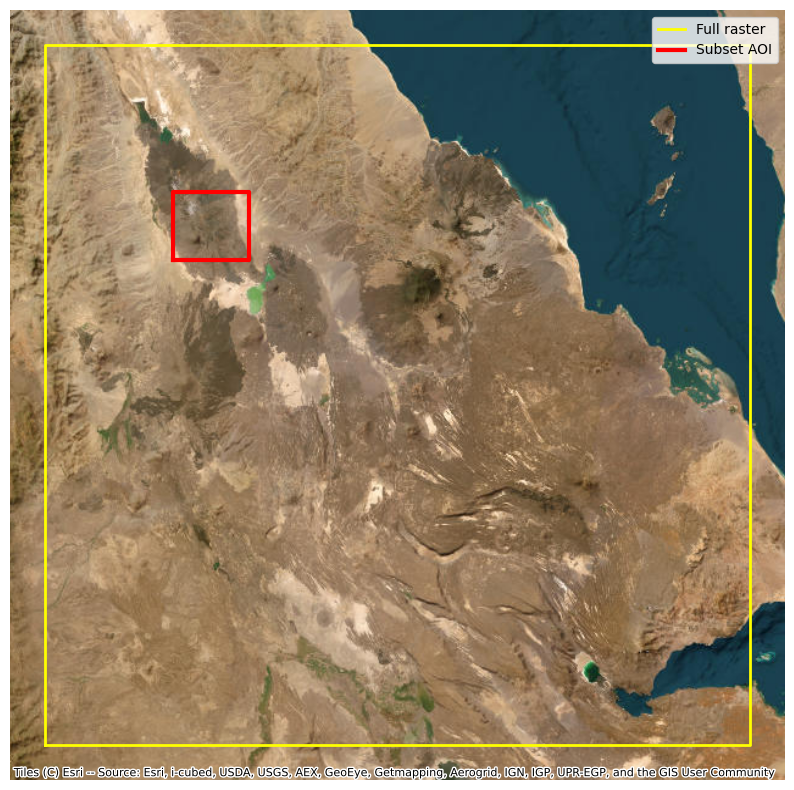

In [13]:
import matplotlib.pyplot as plt
from pyproj import Transformer
import contextily as cx

# Bounds from rioxarray
xmin, ymin, xmax, ymax = ref_file.rio.bounds()
axmin, aymin, axmax, aymax = ref_subset.rio.bounds()

transformer = Transformer.from_crs(
    ref_file.rio.crs,
    "EPSG:3857",
    always_xy=True
)

# Transform bounds
xmin_wm, ymin_wm = transformer.transform(xmin, ymin)
xmax_wm, ymax_wm = transformer.transform(xmax, ymax)

axmin_wm, aymin_wm = transformer.transform(axmin, aymin)
axmax_wm, aymax_wm = transformer.transform(axmax, aymax)

fig, ax = plt.subplots(figsize=(10, 10))

ax.plot(
    [xmin_wm, xmax_wm, xmax_wm, xmin_wm, xmin_wm],
    [ymin_wm, ymin_wm, ymax_wm, ymax_wm, ymin_wm],
    linewidth=2,
    color="yellow",
    label="Full raster"
)

ax.plot(
    [axmin_wm, axmax_wm, axmax_wm, axmin_wm, axmin_wm],
    [aymin_wm, aymin_wm, aymax_wm, aymax_wm, aymin_wm],
    linewidth=3,
    color="red",
    label="Subset AOI"
)

cx.add_basemap(
    ax,
    source=cx.providers.Esri.WorldImagery,
)

ax.legend(loc="upper right")
ax.set_axis_off()
plt.show()

(gslcifg-subsetifg)=
## 7. Create and Visualize a Subsetted Interferogram

In this section, the reference and secondary GSLCs are combined to generate an interferogram for the selected area of interest.

<br>

### 7a. Form the Subsetted Interferogram

Create the interferogram by multiplying the reference GSLC by the complex conjugate of the secondary GSLC. This preserves the phase difference between the two acquisitions.

In [14]:
import numpy as np

ifg_subset = ref_subset * np.conj(sec_subset)

ifg_subset

<xarray.DataArray 'HH' (yCoordinates: 6440, xCoordinates: 3676)> Size: 189MB
dask.array<mul, shape=(6440, 3676), dtype=complex64, chunksize=(4096, 2026), chunktype=numpy.ndarray>
Coordinates:
  * yCoordinates  (yCoordinates) float64 52kB 1.516e+06 1.516e+06 ... 1.484e+06
  * xCoordinates  (xCoordinates) float64 29kB 6.657e+05 6.658e+05 ... 7.025e+05
    projection    int64 8B 0
Attributes:
    description:  Focused SLC image (HH)
    long_name:    Geocoded single-look complex image HH
    units:        1

### 7b. Extract the Interferometric Phase

The interferogram is a complex-valued dataset. To visualize phase differences, compute the phase angle of each pixel. Phase values are wrapped to the range $-\pi$ to $\pi$.

In [15]:
phase_subset = xr.apply_ufunc(
    np.angle,
    ifg_subset,
    dask="allowed",
)

### 7c. Visualize the Wrapped Subsetted Interferogram

Display the wrapped interferometric phase. Areas with similar colors have similar phase values, while rapid color transitions indicate strong phase gradients or deformation signals.

Text(0.5, 1.0, 'Wrapped Subsetted Interferogram')

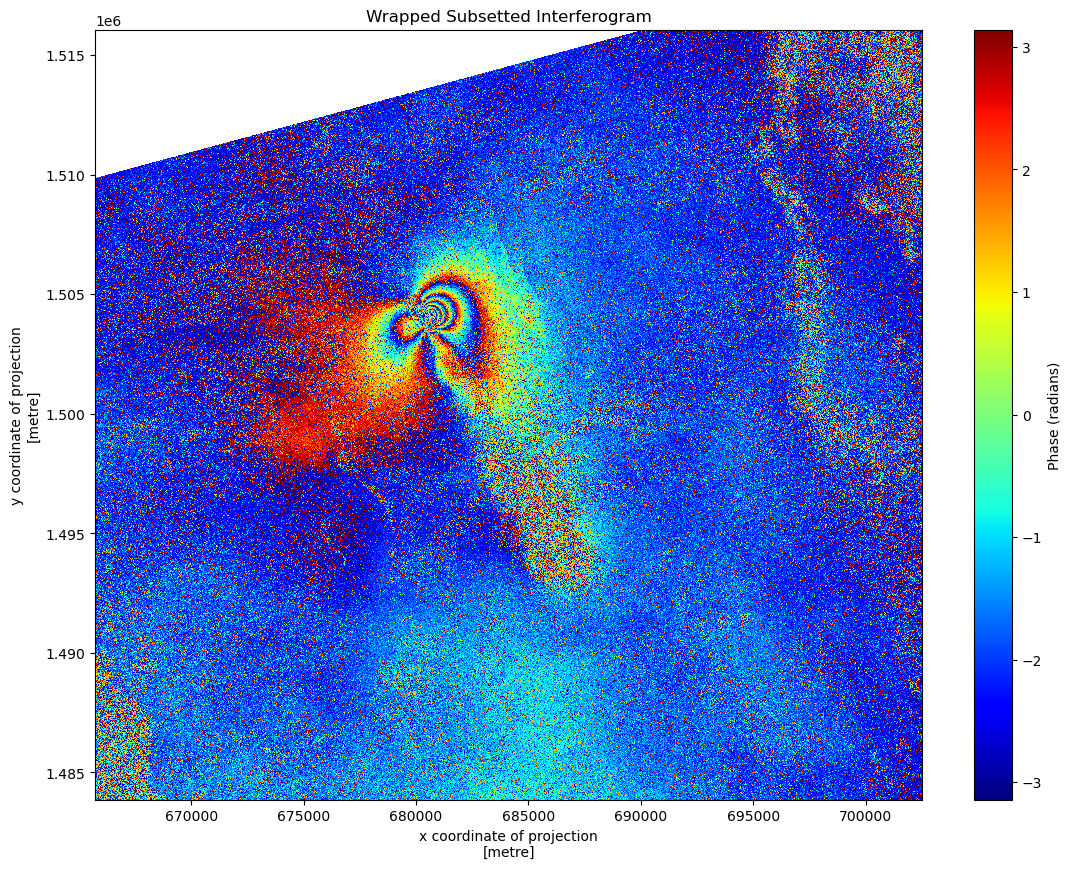

In [16]:
phase_subset.plot.imshow(
    cmap="jet",
    vmin=-np.pi,
    vmax=np.pi,
    size=10,
    cbar_kwargs={"label": "Phase (radians)"}
)

plt.title("Wrapped Subsetted Interferogram")

(gslcifg-sceneifg)=
## 8. Create and Visualize a Scene-Wide Interferogram
In this section, the reference and secondary GSLCs are combined to generate an interferogram for entire NISAR scene. Note that processing times will be longer for this section due to the large size of NISAR GSLC files.

<br>


### 8a. Form the Scene-Wide Interferogram 
Create the interferogram by multiplying the reference GSLC by the complex conjugate of the secondary GSLC. This preserves the phase difference between the two acquisitions.

In [17]:
ifg_scene = ref_file * np.conj(sec_file)

ifg_scene

<xarray.DataArray 'HH' (yCoordinates: 66816, xCoordinates: 34128)> Size: 18GB
dask.array<mul, shape=(66816, 34128), dtype=complex64, chunksize=(4096, 4096), chunktype=numpy.ndarray>
Coordinates:
  * yCoordinates  (yCoordinates) float64 535kB 1.588e+06 1.588e+06 ... 1.254e+06
  * xCoordinates  (xCoordinates) float64 273kB 6.041e+05 6.041e+05 ... 9.454e+05
    projection    int64 8B 0
Attributes:
    description:  Focused SLC image (HH)
    long_name:    Geocoded single-look complex image HH
    units:        1

### 8b. Compute the Full-Resolution Interferometric Phase
The full-resolution interferogram is large and can be slow to display. For visualization, we multilook the interferogram by averaging blocks of complex pixels. This reduces noise and decreases the dataset size before plotting. Because interferometric phase is circular, the complex interferogram is averaged before computing the phase angle.

In [18]:
phase_scene = xr.apply_ufunc(
    np.angle,
    ifg_scene,
    dask="allowed",
)

### 8c. Multilook and Visualize the Scene-Wide Interferogram

Displaying the full-resolution scene can be slow, especially when streaming data over HTTPS. For visualization, the complex interferogram is multilooked by averaging groups of neighboring pixels before computing the phase. This reduces noise and the amount of data that must be displayed while preserving the circular nature of the phase.

If plotting is slow, increase the coarsening factors (`yCoordinates` and `xCoordinates`) below. Larger values will display more quickly but will reduce spatial detail.

CPU times: user 1min 31s, sys: 28.2 s, total: 1min 59s
Wall time: 2min 25s


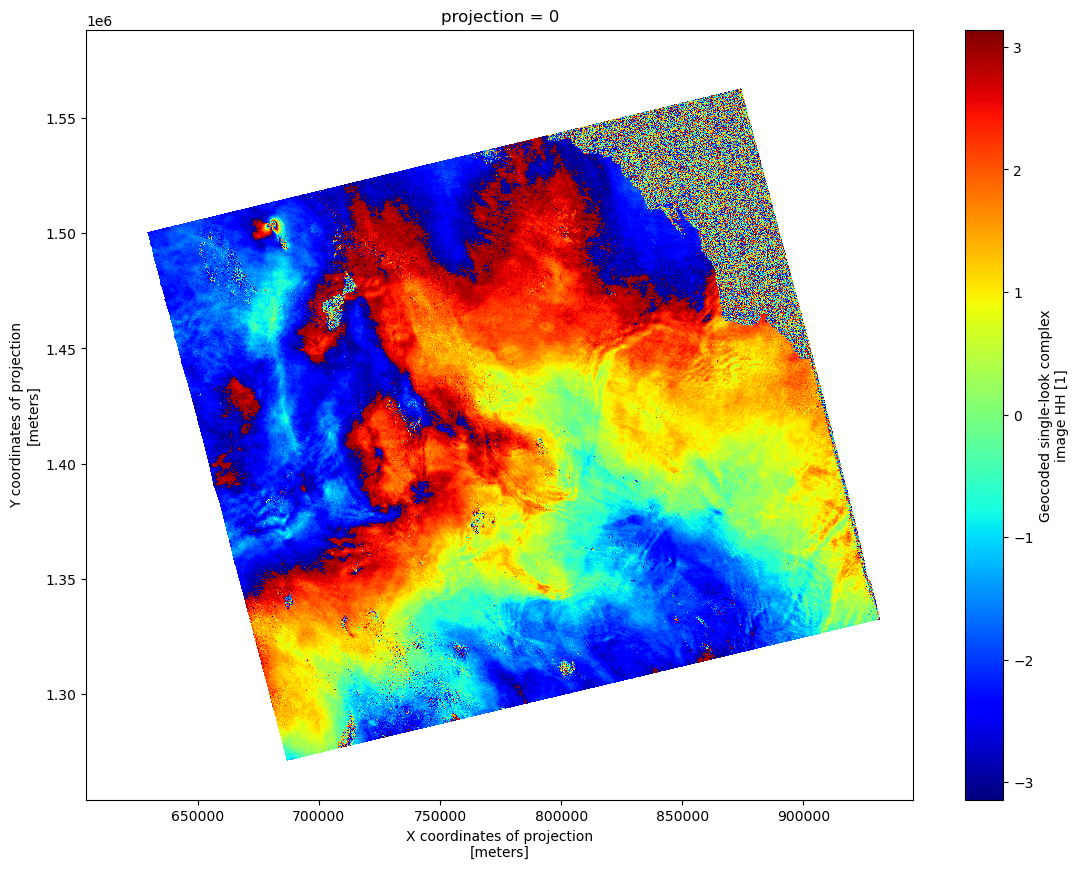

In [19]:
%%time
# multilook
phase_multilook = ifg_scene.coarsen(
    yCoordinates=10,
    xCoordinates=10,
    boundary="trim"
).mean()

# Find phase angles
phase_multilook_radians = xr.apply_ufunc(
    np.angle,
    phase_multilook,
    dask="allowed",
)

# plot
phase_multilook_radians.plot.imshow(
    cmap="jet",
    vmin=-np.pi,
    vmax=np.pi,
    size=10
)

(gslcifg-exports)=
## 9. Export Files

The interferograms generated in this notebook can be exported for use in GIS software, additional processing workflows, or archival purposes. This section demonstrates how to save both the subsetted and scene-wide interferograms as GeoTIFF and/or HDF5 files.

Note: To open the following h5 files in QGIS, rename the ".h5" extension to "nc." For more information, see the *Using NISAR Data* section of the [NISAR Data User Guide](https://nisar-docs.asf.alaska.edu/using-overview/). 

<br>


:::{note}
NISAR data stores coordinates at the center of each pixel. `rioxarray` also works with pixel-center coordinates, so no manual half-pixel shift is needed in this notebook. Other geospatial tools and workflows (such as those using Rasterio or GDAL affine transforms) often reference the upper-left corner of each pixel. When using other geospatial tools, verify whether a half-pixel shift is required before exporting.


**Write crs before exporting**

In [20]:
phase_subset_export = phase_subset.rio.write_crs(f"EPSG:{epsg}")

In [21]:
phase_scene_export = phase_scene.rio.write_crs(f"EPSG:{epsg}")

### 9a. Export Subsetted Interferogram as GeoTIFF

In [22]:
phase_subset_export.rio.to_raster(
    "phase_subset.tif",
    compress="deflate"
)

### 9b. Export Subsetted Interferogram as h5 

In [23]:
phase_subset_export.to_netcdf(
    "phase_subset.h5",
    engine="h5netcdf"
)

### 9c. Export Scene-Wide Interferogram as GeoTIFF

:::{warning}
The processing time for exporting the scene-wide interferogram asa GeoTIFF can take several hours. Consider exporting as an .h5 file, if possible. We do not recommend executing this export locally.
:::

In [21]:
%%time
phase_scene_export.rio.to_raster(
    "phase_scene.tif",
    driver="GTiff",
    tiled=True,
    windowed=True,
    BIGTIFF="YES",
)

CPU times: user 6h 13min 39s, sys: 27min 32s, total: 6h 41min 11s
Wall time: 6h 41min 46s


### 9d. Export Scene-Wide Interferogram as h5

In [24]:
%%time
# ~8MB chunks
phase_scene_h5 = phase_scene.chunk({
    "yCoordinates": 1440,
    "xCoordinates": 1440
})

phase_scene_h5.to_netcdf(
    "phase_scene.h5",
    engine="h5netcdf"
)

CPU times: user 1min 46s, sys: 55.1 s, total: 2min 41s
Wall time: 5min 44s


(gslcifg-summary)=
## 10. Summary
You have now learned how to generate an interferogram using a pair of NISAR GSLC products. This workflow demonstrated how to access GSLC data, select a polarization and area of interest, create and visualize a wrapped interferogram, and export the results for use in downstream analyses.

<br>


(gslcifg-resources)=
## 11. Resources and references
- [xarray](https://docs.xarray.dev/en/stable/)
- [rioxarray](https://corteva.github.io/rioxarray/html/rioxarray.html)
- [NISAR Data User Guide](https://nisar-docs.asf.alaska.edu/)
- [Hayli Gubbi Volcano](https://www.earthdata.nasa.gov/news/worldview-image-archive/first-documented-eruption-ethiopias-hayli-gubbi-volcano)

**Author:** Julia White, Alex Lewandowski